# EC1036 - Inteligência Computacional
## Tópico: Introdução à inteligência artificial

## Generalização de um modelo de aprendizado de máquina

Uma das principais saídas obtidas após o treinamento de um modelo de aprendizado de máquina são os valores da sua função de perda (*loss function*) após cada iteração ao longo do dataset de treino e validação. Com esses valores é possível construir gráficos como visto abaixo.

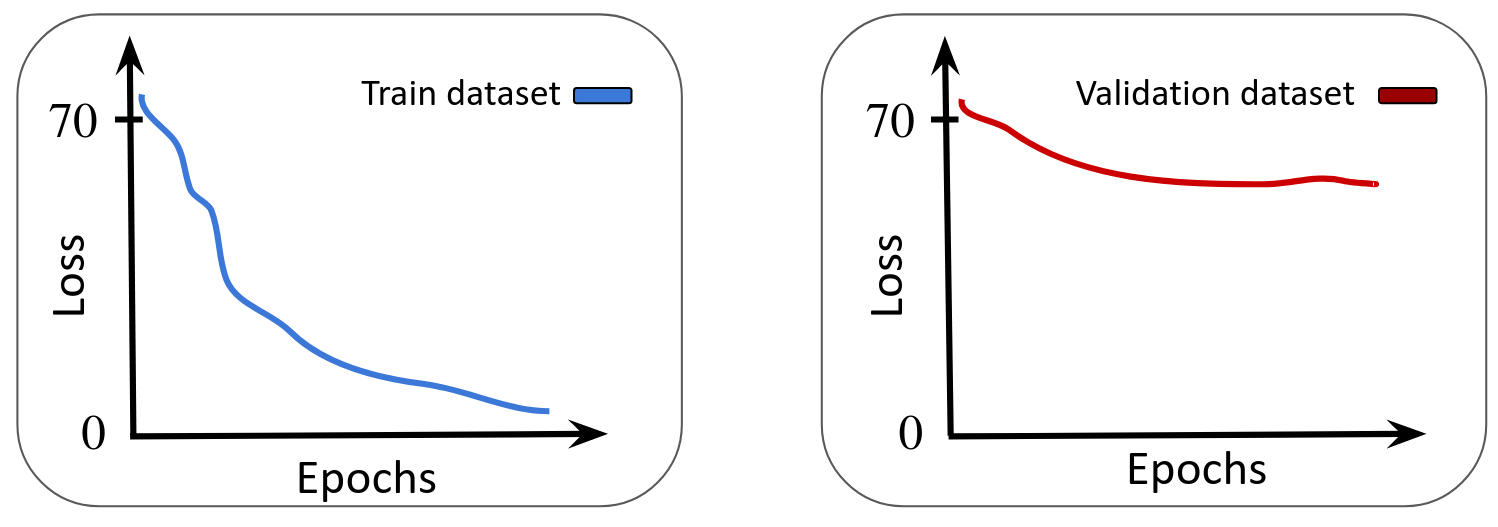

A partir desses gráficos, é possível avaliar empiricamente o desempenho desses modelos, no que diz respeito ao grau de generalização destes. Em suma, dado que o modelo foi treinado com um determinado dataset, este mesmo modelo consegue generalizar tantos outros. Nesse sentido, um indicativo negativo disso é o comportamento dos gráficos acima.

Considerando que quanto mais próximo de zero a função de perda melhor, os gráficos acima mostram um comportamente ímpar. Enquanto que no conjunto de treino a função de perda do modelo converge para zero, no conjunto de valição isso não ocorre. Portanto, nesse exemplo, temos o clássico comportamento de overffiting, em que o grau de generalização do modelo é aceitável apenas no conjunto de treino.

**Logo, dado esse contexto, comente a respeito das possíveis causas para esse tipo de comportamento e que soluções poderiam ser adotadas para mitigá-lo.**

## Divisão de um dataset
Considerando que um dataset está disponível e devidamente pré-processado, um passo importante antes de iniciar o treinamento de um modelo de aprendizado de máquina é a divisão em subconjuntos chamados de treino, validação e teste. Nesse sentido, cada um destes conjuntos possuem uma função especifica para a concepção desse tipo de aprendizado. Logo, considerando que a célula a seguir irá carregar o dataset `iris`, comumente utilizado para uma tarefa de classificação:

**1) Crie uma função que divida o dataset seguindo a seguinte proporção: 70% para treino, 20% para validação e 10% para teste.**
- Defina os parâmetros de entrada (a assinatura de sua função) bem como também os parâmetros de retorno

**2) Aplique a sua função criada e mostre que os subconjuntos obtidos obedecem a proporção requisitada.**
- Se o parâmetro de retorno for uma lista, o método `len()` poderia vir a ser utilizado para tanto.

**3) Compare seus resultados usando o método [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do scikit learn.**


In [1]:
import sklearn
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

data = load_iris()
print(data.keys()) # dataset objects
print(data['DESCR']) # dataset description

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= =====

In [3]:
def split_dataset(dataset: sklearn.utils.Bunch):
    '''
    Split a dataset between train, validation and test
    '''
    # Get total number of samples
    n_of_instances = len(dataset)

    # ratio size for each dataset
    ratio_training_size = 0.7
    ratio_validation_size = 0.2

    n_train = int(ratio_training_size * n_of_instances)
    n_val = int(ratio_validation_size * n_of_instances)

    instance_id = np.arange(0, n_of_instances)

    # Split using the id of each instance
    train_idx = instance_id[:n_train]
    val_idx = instance_id[n_train : n_train + n_val]
    test_idx = instance_id[n_train + n_val :]

    # Split the dataset between input features and labels
    X = dataset.drop("target", axis=1).values
    y = dataset["target"].values

    # Create train, validation and test sets
    X_train = X[train_idx]
    y_train = y[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    # show the requested proportion
    print(f"Training size: {len(X_train)} ({len(X_train) / n_of_instances * 100:.1f}%)")
    print(f"Validation size: {len(X_val)} ({len(X_val) / n_of_instances * 100:.1f}%)")
    print(f"Test size: {len(X_test)} ({len(X_test) / n_of_instances * 100:.1f}%)")

In [4]:
# splitted dataset showing the requested proportion
# for each subset (train, validation and test)

iris_dataset = pd.DataFrame(
    data= np.c_[data['data'], data['target']],
    columns= data['feature_names'] + ['target']
    )

split_dataset(iris_dataset)

Training size: 105 (70.0%)
Validation size: 30 (20.0%)
Test size: 15 (10.0%)


### Splitted dataset using sklearn methods


In [5]:
from sklearn.model_selection import train_test_split

# splitted dataset using sklearn methods
iris_dataset = pd.DataFrame(
    data= np.c_[data['data'], data['target']],
    columns= data['feature_names'] + ['target']
    )

n_of_instances = len(iris_dataset)

X = iris_dataset.drop("target", axis=1).values
y = iris_dataset["target"].values

# split between train-validation and testing dataset
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=50
)

# split between train and validation dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.22, random_state=50
)

# show the requested proportion
print(f"Training size: {len(X_train)} ({len(X_train) / n_of_instances * 100:.1f}%)")
print(f"Validation size: {len(X_val)} ({len(X_val) / n_of_instances * 100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test) / n_of_instances * 100:.1f}%)")

Training size: 105 (70.0%)
Validation size: 30 (20.0%)
Test size: 15 (10.0%)


## Normalização de um dataset
Um segundo passo natural em uma pipeline de aprendizado de máquina, diz respeito a normalização dos atributos de um dataset; a fim de remover outliers, comportando a faixa dinâmica desses valores em um certo intervalo de modo a acelerar a convergência do modelo. Logo, considerando que a célula a seguir irá carregar o dataset `iris`, comumente utilizado para uma tarefa de classificação:

**1) Crie duas funções que façam a normalização de cada atributo $\mathbf{x}$ (feature) do dataset iris usando os métodos `min-max normalization` e `standardization`.**

**2) Utilize suas funções criadas para normalizar o dataset. E apresente os resultados utilizando um DataFrame usando a biblioteca [Pandas](https://pandas.pydata.org/) a partir do método [`head()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html) retornando os atributos das cinco primeiras instâncias normalizadas.**

**3) Compare seus resultados usando os métodos das classes [`StandardScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) e [`MinMaxScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) do scikit-learn.**

Sabendo que:

$x_{norm} = \dfrac{x_i - \min\{\textbf{x}\}}{\max\{\mathbf{x}\} - \min\{\mathbf{x}\}}$ $\rightarrow$ (min-max normalization)

$x_{norm} = \dfrac{x_i - \mu}{\sigma}$ $\rightarrow$ (standardization)

Em que $x_i \in \mathbf{x}$ e $\mu$, $\sigma$ é a média e o desvio padrão do atributo $\mathbf{x}$, respectivamente.

Ademais, uma vez carregado o dataset, este está organizado em uma estrutura de dados em dicionário do python, em que as chaves 'data' e 'target', são respectivamente os atributos e os respectivos rótulos de cada instância.

In [6]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()
print(data.keys()) # dataset objects
print(data['DESCR']) # dataset description

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= =====

In [7]:
X = data["data"]  # input features
y = data["target"]  # labels

In [8]:
def min_max_normalization(X: np.ndarray) -> np.ndarray:
    '''
    normalize input vector X based on its maximum and minimum values
    '''
    X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

    return X_norm

def standardization(X: np.ndarray) -> np.ndarray:
    '''
    normalize input vector X based on its mean and standard deviation
    '''
    X_std = (X - X.mean(axis=0)) / X.std(axis=0)

    return X_std

In [9]:
# Using the min-Max normalization
X_min_max = min_max_normalization(X)
df_min_max = pd.DataFrame(X_min_max, columns=data["feature_names"])
print("\nMin-Max Normalization first 5 normalized instances:")
display(df_min_max.head())

# Using standardization
X_standardized = standardization(X)
df_standardized = pd.DataFrame(X_standardized, columns=data["feature_names"])
print("\nStandardization first 5 normalized instances:")
display(df_standardized.head())


Min-Max Normalization first 5 normalized instances:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667



Standardization first 5 normalized instances:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [10]:
# Normalized dataset using the sklearn methods shown as pandas DataFrame

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Using MinMaxScaler from scikit-learn
scaler_min_max = MinMaxScaler()
X_min_max_norm = scaler_min_max.fit_transform(X)
df_min_max_sklearn = pd.DataFrame(X_min_max_norm, columns=data["feature_names"])
print("\nMin-Max First 5 normalized instances using min-max normalization:")
display(df_min_max_sklearn.head())

# Using StandardScaler from scikit-learn
scaler_standard = StandardScaler()
X_standard_norm = scaler_standard.fit_transform(X)
df_standard_sklearn = pd.DataFrame(X_standard_norm, columns=data["feature_names"])
print("\nFirst 5 normalized instances using standardization:")
display(df_standard_sklearn.head())


Min-Max First 5 normalized instances using min-max normalization:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667



First 5 normalized instances using standardization:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


# Impacto na normalização em um modelo

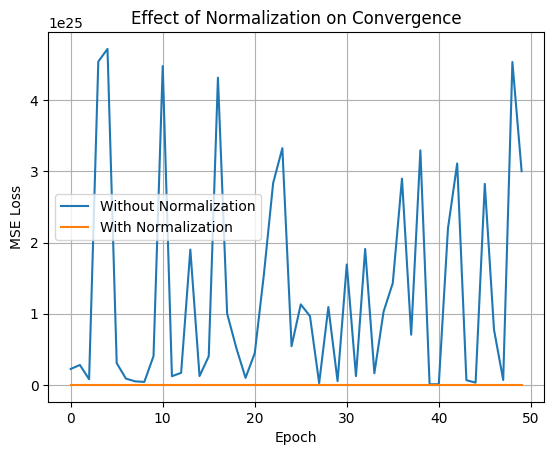

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# --------------------------
# 1. Create synthetic dataset
# --------------------------
np.random.seed(42)

n_samples = 200

# Feature 1: small scale (age-like)
x1 = np.random.uniform(18, 60, n_samples)

# Feature 2: large scale (salary-like)
x2 = np.random.uniform(2000, 50000, n_samples)

# Stack features
X = np.column_stack((x1, x2))

# True relationship
y = 3 * x1 + 0.05 * x2 + np.random.randn(n_samples) * 10

# Training function
def train_and_track(X, y, normalize=False):
    if normalize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    model = SGDRegressor(max_iter=1, tol=None, eta0=0.00000001, learning_rate='constant', random_state=42)

    losses = []

    for epoch in range(50):
        model.partial_fit(X, y)
        y_pred = model.predict(X)
        loss = mean_squared_error(y, y_pred)
        losses.append(loss)

    return losses

# Train both versions
loss_no_norm = train_and_track(X, y, normalize=False)
loss_norm = train_and_track(X, y, normalize=True)

# Plot comparison
plt.plot(loss_no_norm, label="Without Normalization")
plt.plot(loss_norm, label="With Normalization")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Normalization on Convergence")
plt.legend()
plt.grid()

plt.show()

## Treinando seu primeiro modelo de aprendizado de máquina

Com intuito de obter um sentimento a respeito do treinamento de um modelo de aprendizado de máquina, o exercíco a seguir mostra um treinamento simples utilizando um modelo de regressão logística [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), considerando o dataset `iris` utilizado nas questões acima, para realizar uma tarefa de classificação multiclasse.

Desse modo, o código a seguir é dividido em quatro principais partes:
- O carregamento do dataset
- A divisão do dataset entre treino e teste
- O treinamento do modelo
- A obtenção das métricas de performance

Definida essa estrutura, implemente as modificações a seguir, considerando o dataset de teste **(seja cuidadoso, os resultados como a matriz de confusão e acurácia obtidos a partir do código base utilizaram o dataset de treino;modifique o código a fim de utilizar o dataset de teste para fazer os experimentos a seguir)**:

**1) O código base mencionado propôs uma divisão do dataset iris, entre treino e teste, seguindo um proporção de $\frac{1}{2}$ para cada subconjunto. Modifique essa proporção para um valor plausível (e.g $\frac{3}{4}$, 75% treino e 25% teste, $\frac{4}{5}$, $\dots$) para cada subconjunto. Feito isso, retreine o modelo e salve os resultados de acurácia em uma estrutura de dados conveniente.**

**2) O código base utiliza como entrada apenas duas features das quatro disponíveis, `petal length` e `petal width`. Faça uma modificação no código de modo que as features de entrada sejam apenas `sepal length` e `sepal width`. Feito isso, retreine o modelo e salve os resultados de acurária em uma estrutura de dados conveniente.**

**3) Repita o processo feito (2) assumindo agora como entrada do modelo todas as quatro features disponíveis `petal length`, `petal width`, `sepal length` e `sepal width`. Feito isso, retreine o modelo e salve os resultados de acurácia em uma estrutura de dados conveniente.**

**4) Uma vez em posse de todos os resultados, crie um DataFrame pandas condensando todos resultados obtidos para cada experimento. Em uma estrutura similar a esta abaixo:**

|               | Accuracy  |
|---------------|-----------|
| Experimento 1 | -         |
| Experimento 2 | -         |
| Experimento 3 | -         |



**Comente os resultados e avalie em qual experimento o modelo obteve a melhor performance e as razões para tanto.**

### Carregando o dataset
Este dataset contém 150 instâncias, cada uma contendo 4 features.

In [16]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

# loading iris dataset
data = load_iris()

# converting to pandas DataFrame
iris = pd.DataFrame(
    data= np.c_[data['data'], data['target']],
    columns= data['feature_names'] + ['target']
    )

# show the first 10 instances
iris.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
5,5.4,3.9,1.7,0.4,0.0
6,4.6,3.4,1.4,0.3,0.0
7,5.0,3.4,1.5,0.2,0.0
8,4.4,2.9,1.4,0.2,0.0
9,4.9,3.1,1.5,0.1,0.0


In [17]:
species = []

# converting the numerical labels to string
# for each type of flower
for i in range(len(iris['target'])):
    if iris['target'][i] == 0:
        species.append("setosa")
    elif iris['target'][i] == 1:
        species.append('versicolor')
    else:
        species.append('virginica')

# adding the species name to the dataset
iris['species'] = species

iris.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa
5,5.4,3.9,1.7,0.4,0.0,setosa
6,4.6,3.4,1.4,0.3,0.0,setosa
7,5.0,3.4,1.5,0.2,0.0,setosa
8,4.4,2.9,1.4,0.2,0.0,setosa
9,4.9,3.1,1.5,0.1,0.0,setosa


In [18]:
# display the instances for each class
iris.groupby('species').size()

species
setosa        50
versicolor    50
virginica     50
dtype: int64

## Experimento 1

**1) O código base mencionado propôs uma divisão do dataset iris, entre treino e teste, seguindo um proporção de $\frac{1}{2}$ para cada subconjunto. Modifique essa proporção para um valor plausível (e.g $\frac{3}{4}$, 75% treino e 25% teste, $\frac{4}{5}$, $\dots$) para cada subconjunto. Feito isso, retreine o modelo e salve os resultados de acurácia em uma estrutura de dados conveniente.**

### Dividindo o conjunto em treino e teste

In [19]:
from sklearn.model_selection import train_test_split

# as this is a supervised learning, only the features
# are use in the training process, so the labels are dropped
X = iris.drop(['target','species'], axis=1)

# converting the input features to a numpy array
# using only petal length and petal width as input features
X = X.to_numpy()[:, (2,3)]

# assigning the labels in a variable
y = iris['target']

# splitting the dataset following the proportion
# of 50% for training and 50% for testing
# also setting a seed for replicability of the results
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,
                                                    random_state=42)

### Treinando o modelo

In [20]:
from sklearn.linear_model import LogisticRegression

# loading the model
log_reg = LogisticRegression()

# training the model using the method fit()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Testando o modelo

In [21]:
# once trained, we can use it to predict the
# class of the test dataset
testing_prediction = log_reg.predict(X_test)

### Obtendo métricas de performance
Na área de aprendizado de máquina, a depender do tipo de tarefa, há diferentes métricas para avaliar o quão bem está a performance do modelo. Nesse sentido, para tarefas de classificação há três [métricas comumente utilizadas](https://www.analyticsvidhya.com/blog/2021/07/metrics-to-evaluate-your-classification-model-to-take-the-right-decisions/), **precision**, **recall** e **f1-score**.

Ademais, tais métricas podem ser obtidas a partir da [matriz de confusão](https://www.ibm.com/br-pt/topics/confusion-matrix) que descreve a performance do modelo sob um dado dataset.

Precision, Recall, Confusion matrix, in training

              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000        15
         1.0      1.000     1.000     1.000        11
         2.0      1.000     1.000     1.000        12

    accuracy                          1.000        38
   macro avg      1.000     1.000     1.000        38
weighted avg      1.000     1.000     1.000        38

Accuracy: 1.0


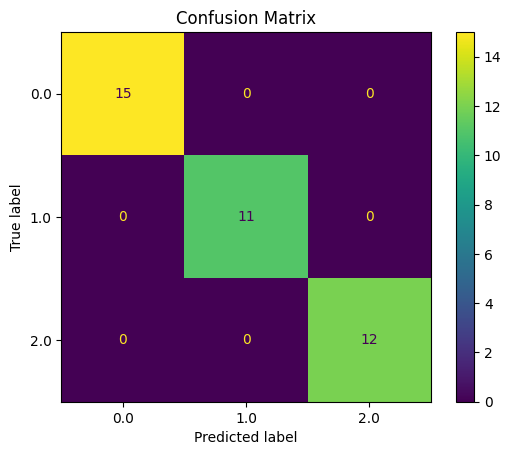

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, \
                                        accuracy_score, classification_report
from matplotlib import pyplot as plt

print("Precision, Recall, Confusion matrix, in training\n")

# get precision, recall and f1-score scores
print(classification_report(y_test, testing_prediction, digits=3))

# get only the model accurary on the test dataset
print(f'Accuracy: {np.round(accuracy_score(y_test, testing_prediction), 3)}')
exp_1_acc_score = np.round(accuracy_score(y_test, testing_prediction), 3)

# plot the confusion matrix
cm = confusion_matrix(y_test, testing_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_reg.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# Experimento 2

**2) O código base utiliza como entrada apenas duas features das quatro disponíveis, `petal length` e `petal width`. Faça uma modificação no código de modo que as features de entrada sejam apenas `sepal length` e `sepal width`. Feito isso, retreine o modelo e salve os resultados de acurária em uma estrutura de dados conveniente.**

**Obs: Neste experimento foi considerado a mesma proporção de treino e teste do modelo base, isto é, 50% para cada conjunto. Como não foi especificado explicitamente que tal proporção deveria ser seguida, outras proporções poderiam vir a ser utilizadas.**

In [23]:
from sklearn.model_selection import train_test_split

# as this is a supervised learning, only the features
# are use in the training process, so the labels are dropped
X = iris.drop(['target','species'], axis=1)

# converting the input features to a numpy array
# using only sepal length and sepal width as input features
X = X.to_numpy()[:, (0,1)]

# assigning the labels in a variable
y = iris['target']

# splitting the dataset following the proportion
# of 50% for training and 50% for testing
# also setting a seed for replicability of the results
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,
                                                    random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression

# loading the model
log_reg = LogisticRegression()

# training the model using the method fit()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
# once trained, we can use it to predict the
# class of the test dataset
testing_prediction = log_reg.predict(X_test)

### Obtendo métricas de performance
Na área de aprendizado de máquina, a depender do tipo de tarefa, há diferentes métricas para avaliar o quão bem está a performance do modelo. Nesse sentido, para tarefas de classificação há três [métricas comumente utilizadas](https://www.analyticsvidhya.com/blog/2021/07/metrics-to-evaluate-your-classification-model-to-take-the-right-decisions/), **precision**, **recall** e **f1-score**.

Ademais, tais métricas podem ser obtidas a partir da [matriz de confusão](https://www.ibm.com/br-pt/topics/confusion-matrix) que descreve a performance do modelo sob um dado dataset.

Precision, Recall, Confusion matrix, in training

              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000        29
         1.0      0.714     0.652     0.682        23
         2.0      0.680     0.739     0.708        23

    accuracy                          0.813        75
   macro avg      0.798     0.797     0.797        75
weighted avg      0.814     0.813     0.813        75

Accuracy: 0.813


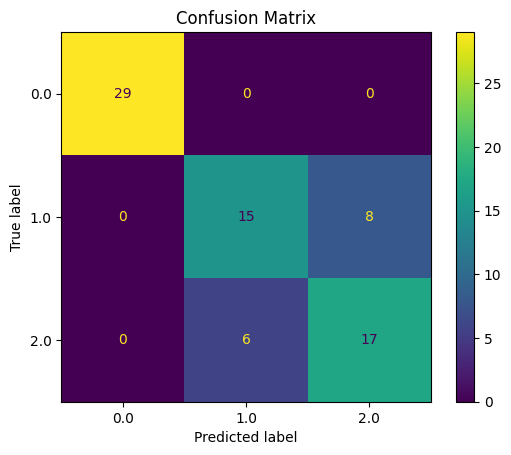

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, \
                                        accuracy_score, classification_report
from matplotlib import pyplot as plt

print("Precision, Recall, Confusion matrix, in training\n")

# get precision, recall and f1-score scores
print(classification_report(y_test, testing_prediction, digits=3))

# get only the model accurary on the testing dataset
print(f'Accuracy: {np.round(accuracy_score(y_test, testing_prediction), 3)}')
exp_2_acc_score = np.round(accuracy_score(y_test, testing_prediction), 3)


# plot the confusion matrix
cm = confusion_matrix(y_test, testing_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_reg.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# Experimento 3
**3) Repita o processo feito (2) assumindo agora como entrada do modelo todas as quatro features disponíveis `petal length`, `petal width`, `sepal length` e `sepal width`. Feito isso, retreine o modelo e salve os resultados de acurácia em uma estrutura de dados conveniente.**

**Obs: Neste experimento foi considerado a mesma proporção de treino e teste do modelo base, isto é, 50% para cada conjunto. Como não foi especificado explicitamente que tal proporção deveria ser seguida, outras proporções poderiam vir a ser utilizadas.**

In [27]:
from sklearn.model_selection import train_test_split

# as this is a supervised learning, only the features
# are use in the training process, so the labels are dropped
X = iris.drop(['target','species'], axis=1)

# converting the input features to a numpy array
# using all available features
X = X.to_numpy()[:,]

# assigning the labels in a variable
y = iris['target']

# splitting the dataset following the proportion
# of 50% for training and 50% for testing
# also setting a seed for replicability of the results
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,
                                                    random_state=42)

In [28]:
from sklearn.linear_model import LogisticRegression

# loading the model
log_reg = LogisticRegression()

# training the model using the method fit()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
# once trained, we can use it to predict the
# class of test dataset
testing_prediction = log_reg.predict(X_test)

Precision, Recall, Confusion matrix, in training

              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000        29
         1.0      1.000     1.000     1.000        23
         2.0      1.000     1.000     1.000        23

    accuracy                          1.000        75
   macro avg      1.000     1.000     1.000        75
weighted avg      1.000     1.000     1.000        75

Accuracy: 1.0


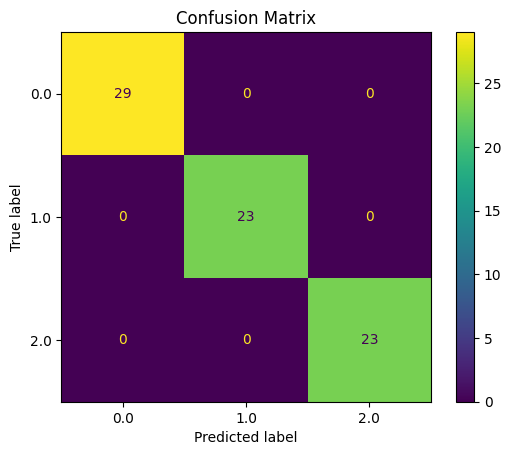

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, \
                                        accuracy_score, classification_report
from matplotlib import pyplot as plt

print("Precision, Recall, Confusion matrix, in training\n")

# get precision, recall and f1-score scores
print(classification_report(y_test, testing_prediction, digits=3))

# get only the model accurary on the training dataset
print(f'Accuracy: {np.round(accuracy_score(y_test, testing_prediction), 3)}')

exp_3_acc_score = np.round(accuracy_score(y_test, testing_prediction), 3)

# plot the confusion matrix
cm = confusion_matrix(y_test, testing_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_reg.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

### Apresentando os resultados

In [31]:
results = {'Experimento': ['Experimento 1', 'Experimento 2', 'Experimentl 3'],
            'Acurácia': [exp_1_acc_score, exp_2_acc_score, exp_3_acc_score]}

df = pd.DataFrame(results)

df.head()

,Experimento,Acurácia
0,Experimento 1,1.000
1,Experimento 2,0.813
2,Experimentl 3,1.000
